In [1]:
#Import Libraries 
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from sklearn.model_selection import GroupShuffleSplit
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns

#Configuration
SEED_VALUE = 42
WINDOW_SIZE = 50           
RUL_CLIPPING_VALUE = 100   
PROCESSED_DATA_PATH = '../data/processed/train_FD001_processed.csv'
MODEL_SAVE_PATH = '../models/best_rul_gru_model.h5'

#Set up random seeds for reproducibility
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/

In [2]:
#Feature Definition

def get_feature_columns(df):
    cols_to_exclude = ['unit_number', 'time_in_cycles', 'RUL', 'RUL_Clipped']
    return [col for col in df.columns if col not in cols_to_exclude]


#Redefine Model Architecture
def build_gru_model(timesteps, features):
    optimizer = Adam(learning_rate=0.0005) 
    
    model = Sequential([
        #GRU Layers 
        GRU(128, input_shape=(timesteps, features), return_sequences=True),
        Dropout(0.3),
        
        GRU(64, return_sequences=False),
        Dropout(0.3),
        
        #Dense layers
        Dense(32, activation='relu'),
        Dense(10, activation='relu'),
        
        Dense(1) 
    ])

    model.compile(optimizer=optimizer, 
                  loss='mse', 
                  metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse'), 'mae'])
    return model

In [3]:
#Load Data and Model

print("Loading data to recreate test set...")
df = pd.read_csv(PROCESSED_DATA_PATH)
df['RUL_Clipped'] = df['RUL'].clip(upper=RUL_CLIPPING_VALUE)

FEATURE_COLUMNS = get_feature_columns(df)
NUM_FEATURES = len(FEATURE_COLUMNS)
TARGET_COLUMN = 'RUL_Clipped'
print(f"Features in use (Total: {NUM_FEATURES}): {FEATURE_COLUMNS[:3]}...")

#Replicate sequence generation to get X, y, groups
def generate_sequences(df, window_size, feature_cols, target_col):
    X, y, groups = [], [], []
    for unit in df['unit_number'].unique():
        unit_data = df[df['unit_number'] == unit]
        features = unit_data[feature_cols].values
        target = unit_data[target_col].values
        unit_groups = unit_data['unit_number'].values
        
        for i in range(len(unit_data) - window_size + 1):
            X.append(features[i : i + window_size])
            y.append(target[i + window_size - 1]) 
            groups.append(unit_groups[i + window_size - 1])
            
    return np.array(X), np.array(y), np.array(groups)

X, y, groups = generate_sequences(df, WINDOW_SIZE, FEATURE_COLUMNS, TARGET_COLUMN)


#Re-split the data to isolate X_test, y_test, and groups_test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED_VALUE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_test = X[test_idx]
y_test = y[test_idx]
groups_test = groups[test_idx]

print(f"Test set (X_test) ready with shape: {X_test.shape}")


#Instantiate the model structure and load weights
best_model = build_gru_model(WINDOW_SIZE, NUM_FEATURES)
print(f"\nLoading weights from: {MODEL_SAVE_PATH}")

#Define custom objects needed for model loading
custom_objects = {
    'rmse': tf.keras.metrics.RootMeanSquaredError(name='rmse'), 
    'mse': tf.keras.losses.MeanSquaredError(),
    'relu': tf.keras.activations.relu
}

try:
    #Load weights into the predefined structure
    best_model = load_model(MODEL_SAVE_PATH, custom_objects=custom_objects)
except Exception as e:
    print(f"ERROR: Failed to load model. Ensure Milestone 2 was run successfully. Details: {e}")
    raise

Loading data to recreate test set...
Features in use (Total: 20): ['op_setting_1', 'op_setting_2', 'op_setting_3']...
Test set (X_test) ready with shape: (3090, 50, 20)


c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Loading weights from: ../models/best_rul_gru_model.h5


In [4]:
#Generate Predictions and Calculate Errors
print("\nGenerating predictions on the test set...")
y_pred = best_model.predict(X_test).flatten()

#Calculate prediction error (Residuals)
errors = y_pred - y_test


Generating predictions on the test set...
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step


In [5]:
#Evaluation Metrics
loss, rmse, mae = best_model.evaluate(X_test, y_test, verbose=0)
test_variance = np.var(y_test)
R2 = 1 - (loss / test_variance)

print("\n--- M3 Deliverable: Calculated RMSE Scores ---")
print(f"Final Test RMSE: {rmse:.4f} cycles (Goal: < 10)")
print(f"Final Test MAE: {mae:.4f} cycles")
print(f"Final Test R² Score: {R2:.4f} (Goal: > 0.95)")


--- M3 Deliverable: Calculated RMSE Scores ---
Final Test RMSE: 7.1094 cycles (Goal: < 10)
Final Test MAE: 4.9010 cycles
Final Test R² Score: 0.9550 (Goal: > 0.95)



--- M3 Deliverable: Visualization: RUL Trends ---


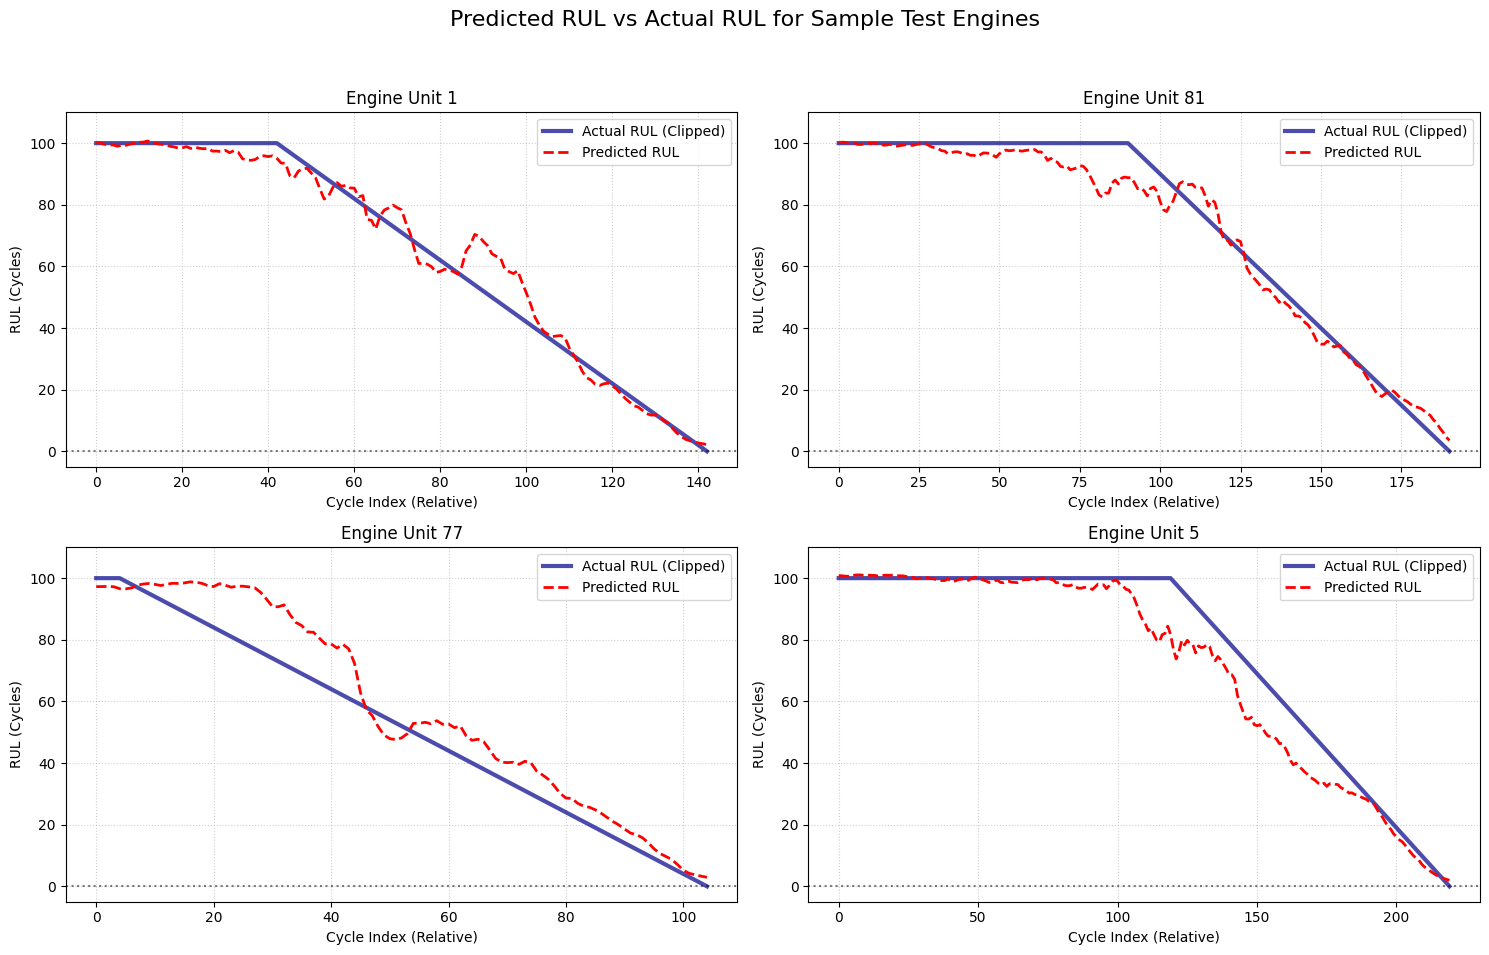

In [6]:
#Visualization: Predicted vs Actual RUL

print("\n--- M3 Deliverable: Visualization: RUL Trends ---")
#Create a DataFrame for easy plotting by engine unit
results_df = pd.DataFrame({
    'unit_number': groups_test, 
    'RUL_Actual': y_test, 
    'RUL_Predicted': y_pred,
})

#Select 4 random engine units from the test set for plotting
plot_units = results_df['unit_number'].unique()
if len(plot_units) < 4:
    units_to_plot = plot_units
else:
    np.random.seed(SEED_VALUE)
    np.random.shuffle(plot_units)
    units_to_plot = plot_units[:4]

plt.figure(figsize=(15, 10))
plt.suptitle('Predicted RUL vs Actual RUL for Sample Test Engines', fontsize=16)

for i, unit_id in enumerate(units_to_plot):
    unit_data = results_df[results_df['unit_number'] == unit_id].reset_index(drop=True)
    
    plt.subplot(2, 2, i + 1)
    
    #Plot Actual RUL
    plt.plot(unit_data.index, unit_data['RUL_Actual'], label='Actual RUL (Clipped)', color='darkblue', linewidth=3, alpha=0.7)
    
    #Plot Predicted RUL
    plt.plot(unit_data.index, unit_data['RUL_Predicted'], label='Predicted RUL', color='red', linestyle='--', linewidth=2)
    
    #Add a marker for the end of life (RUL=0)
    plt.axhline(0, color='black', linestyle=':', alpha=0.5) 
    
    plt.title(f'Engine Unit {unit_id}', fontsize=12)
    plt.xlabel('Cycle Index (Relative)', fontsize=10)
    plt.ylabel('RUL (Cycles)', fontsize=10)
    plt.ylim(-5, RUL_CLIPPING_VALUE + 10) 
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


--- M3 Deliverable: Error Analysis ---


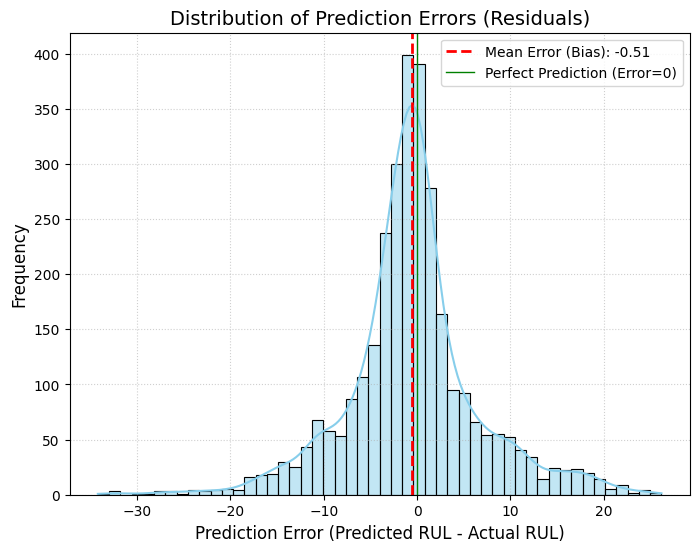


Mean Prediction Error (Bias): -0.5091
Standard Deviation of Errors (Precision): 7.0912

✅ Milestone 3 Evaluation and Analysis Complete!


In [7]:
#Analysis of Model Biases and Errors

print("\n--- M3 Deliverable: Error Analysis ---")

#Plotting the distribution of the errors
plt.figure(figsize=(8, 6))
sns.histplot(errors, kde=True, bins=50, color='skyblue', edgecolor='black')
plt.axvline(errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean Error (Bias): {errors.mean():.2f}')
plt.axvline(0, color='green', linestyle='-', linewidth=1, label='Perfect Prediction (Error=0)')
plt.title('Distribution of Prediction Errors (Residuals)', fontsize=14)
plt.xlabel('Prediction Error (Predicted RUL - Actual RUL)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"\nMean Prediction Error (Bias): {errors.mean():.4f}")
print(f"Standard Deviation of Errors (Precision): {errors.std():.4f}")

print("\n✅ Milestone 3 Evaluation and Analysis Complete!")